__IMPORTING NECESSARY LIBRARIES__

In [24]:
# Libraries for Accessing Dataset & Visualization purposes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

__LOADING DATASET__

In [2]:
data=pd.read_csv("UCI_Credit_Card.csv")
data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


__USING PYTHON METHOS TO DESCRIBE DATASET__

In [3]:
data.info() #Data Types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
data.head() #Command used to print to 5 rows

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
data.tail() #Command used to print bottom 5 rows


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1
29999,30000,50000.0,1,2,1,46,0,0,0,0,...,36535.0,32428.0,15313.0,2078.0,1800.0,1430.0,1000.0,1000.0,1000.0,1


In [6]:
data.describe() #it was used to check the statistical measures like mean,median etc for the respective dataset

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [7]:
# Number of rows and columns
rows, cols = data.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}\n")

Number of rows: 30000
Number of columns: 25



In [8]:
# Data types
print("Data types of each variable:")
print(data.dtypes, "\n")

Data types of each variable:
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object 



__DATA QUALITY__

__CHECKING THE MISSING VALUES__

In [9]:
data.isna().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

From the above information, we can understand that there are no missing values in any of the columns.

__Interpretation based on the above cells__

- The dataset consists of 30000 data points which contain 24 different characteristics.

- The target variable is default.payment.next.month.

- The majority of the variables in the dataset exist as numeric data.

- The system found no major missing values (your situation requires different verification).

- The dataset includes two types of data which are demographic information (AGE, SEX, EDUCATION) and financial behavior data (LIMIT_BAL, PAY_1, BILL_AMT1-6).

__This dataset is suitable for classification analysis because:__

- The target variable has two possible outcomes which form a complete distribution of data points.

- The number of data points exceeds the required threshold for statistical analysis.

- The dataset includes both financial data and demographic information as independent variables.

- The dataset establishes credit risk assessment procedures which correspond to actual world practices.

__TARGET VARIABLE DISTRIBUTION__

__CLASS DISTRIBUTION__

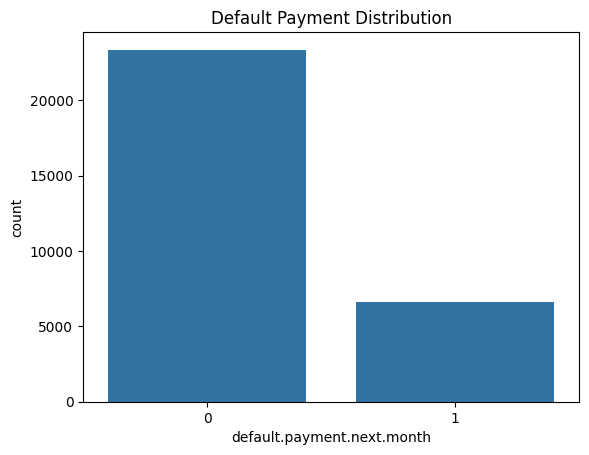

In [10]:
sns.countplot(x='default.payment.next.month', data=data)
plt.title("Default Payment Distribution")
plt.show()

__Observation:__

- Majority class = Non-default (0)

- Minority class = Default (1)

- The class distribution shows 78% of individuals as non-default and 22% as default.

__Insights:__

- The dataset exhibits an imbalance problem.

- Accuracy does not function as a complete evaluation metric.

- The system needs both recall and F1-score to identify defaulters with precision.

- The system tends to show a preference for predicting non-default outcomes.

__AGE DISTRIBUTION__

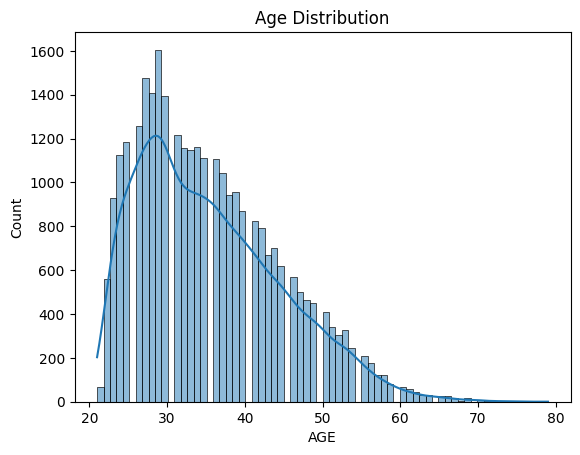

In [11]:
sns.histplot(data['AGE'], kde=True)
plt.title("Age Distribution")
plt.show()

__Interpretation__

- The age distribution shows a slight rightward skewing pattern. 

- Customers between the ages of 25 and 40 form the largest group of customers. 

- Only a small number of customers reach the age of 60. 

__Insights__

- The dataset contains data which shows that younger working people make up the largest portion of the dataset. 

- Age acts as a factor which affects credit risk assessment. 

- People at both ends of the age spectrum will exhibit distinct patterns when they repay their debts.

__CREDIT LIMIT DISTRIBUTION__

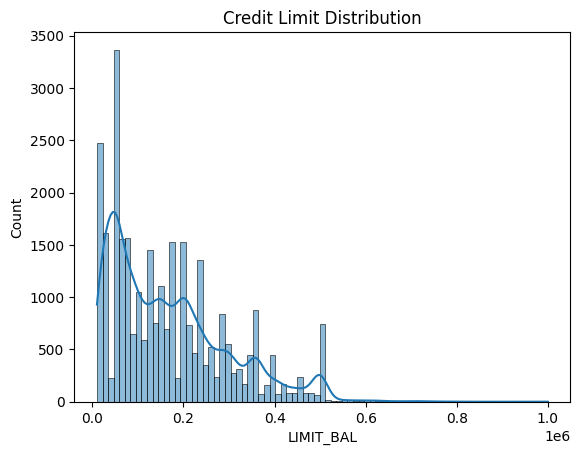

In [12]:
sns.histplot(data['LIMIT_BAL'], kde=True)
plt.title("Credit Limit Distribution")
plt.show()

__Observation__

- The graph shows that the data distribution exhibits a strong rightward skew. 

- The majority of customers possess lower credit limits than their established limits.

- A small number of customers receive their credit limits at extremely high values.

__Insights__

- The data contains outliers which need to be removed.

- The process requires feature scaling to be implemented.

- Customers with high credit limits show different patterns of defaulting on their payments.

__CORRLEATION BY HEATMAP__

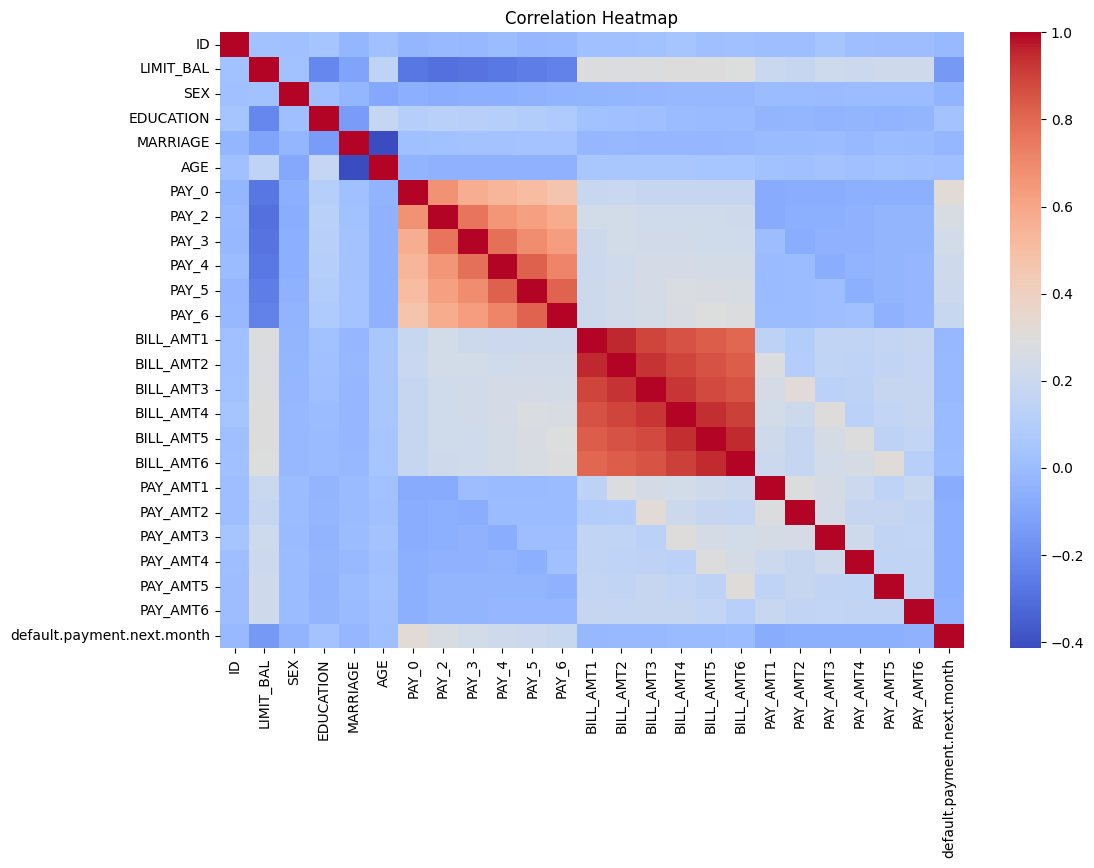

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

__Observation__

- Strong correlations among the six billing amount variables which include BILL_AMT1 through BILL_AMT6.

- Strong correlations among the six payment amount variables which include PAY_AMT1 through PAY_AMT6.

- The variables which measure payment delay show some degree of moderate correlation.

__Insights__

- The data contains multiple variables which show multicollinearity.

- Tree-based models show better performance with this data.

- The results of logistic regression analysis will show different outcomes.

- The performance of the system will increase through feature selection and regularization. 

__DEFAULT RATE BY GENDER__

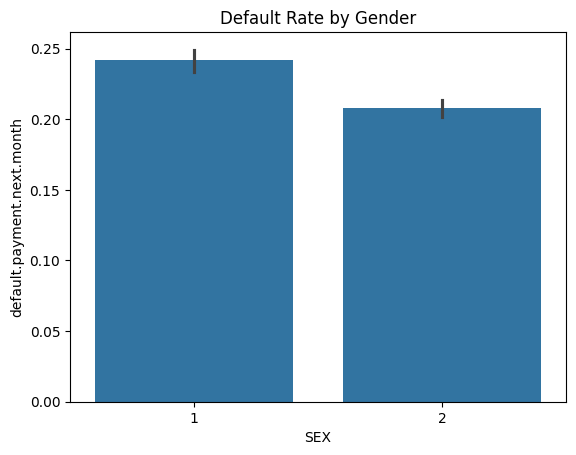

In [14]:
sns.barplot(x='SEX', y='default.payment.next.month', data=data)
plt.title("Default Rate by Gender")
plt.show()

__Human interpretation__

- One gender may show slightly higher default rate.

- The difference between two groups does not reach extreme levels.


__Insights__


- Gender may contribute predictive value.

-  ethical evaluation requires assessment of model fairness.

__PAYMENT DELAY IMPACT__

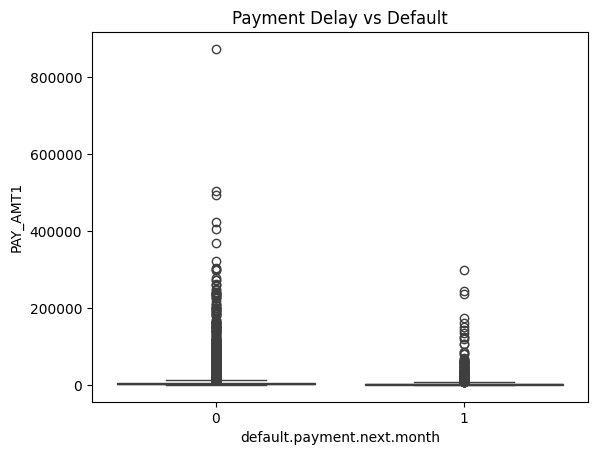

In [15]:
sns.boxplot(x='default.payment.next.month', y='PAY_AMT1', data=data)
plt.title("Payment Delay vs Default")
plt.show()

__Observation__

- Customers who default have higher PAY_1 values.

- The relationship between late payments and defaulting shows strong correlation.

__Insights__

- The payment history serves as a powerful predictor of future outcomes.

- The recent payment delay stands as the most significant element of this analysis.

- The feature importance analysis will verify this finding with later results.

__DATA INSIGHTS__

- The dataset shows class imbalance which requires precise evaluation through three metrics because accuracy does not provide sufficient information.

- Financial variables that include payment delays and bill amounts demonstrate strong relationships which enable accurate prediction of outcomes.

- The billing features show evidence of multicollinearity.

- Default prediction depends mainly on two factors credit limit and payment history.

- Demographic variables show some predictive power but financial behavior patterns serve as more informative indicators of credit risk.

__Conclusion__

The exploratory data analysis demonstrates that the dataset meets requirements for machine learning classification testing. Payment history variables demonstrate high predictive accuracy while financial attributes exhibit multicollinearity. The presence of class imbalance requires evaluation metrics that extend beyond accuracy measurements. The findings support using both linear and ensemble-based models for the upcoming modeling stage.

__3. ML MODELING__

__DATA PREPARATION__

__Before model training:__

- The process requires the separation of features from the target variable.

- The process requires the creation of two separate datasets which maintain the original class distribution of the data.

- The process needs to execute feature scaling because it is essential for both logistic regression and support vector machine algorithms.

__Feature Split__

In [16]:
# Features and target
X = data.drop("default.payment.next.month", axis=1)
y = data["default.payment.next.month"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

__Feature Scaling__

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaling is required because:

- Logistic Regression and SVM require distance calculations as their fundamental operation.

- The features of the system display different range values between LIMIT_BAL and PAY_1.

__BASELINE MODEL: LOGISTIC REGRESSION__

- The system functions as a basic linear classification system.

- The system provides simple results which users can easily understand.

- The system generates probability scores as its output.

- The system uses Log Loss (Cross-Entropy Loss) as its primary loss function for optimization.

Loss=−∑(ylog(p)+(1−y)log(1−p))

__CODE__

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

__Interpretation__

- There is a linear relationship between the features and log-odds, according to this assumption.

- If the relationships are nonlinear, it may be underperforming.

- But one can be used as the benchmark for comparison purposes.

__MODEL 2:  DECISION TREE CLASSIFIER__

__Justification__

- Captures non-linear relationships

- No scaling required

- Easy to visualize and interpret

- Uses Gini Index or Entropy

__CODE__

In [19]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

__Interpretation__

- The system maintains low bias while showing high variance results. 

- The system will develop overfitting problems when its depth settings remain uncontrolled. 

__MODEL 3: RANDOM FOREST__ 

__Justification__

- The system integrates several decision trees to create its operational framework. 

- The process reduces the risk of overfitting through its implemented functions. 

- The system can manage multiple correlated variables without experiencing performance problems. 

- The system demonstrates excellent ability to perform well on new data.

__CODE__

In [20]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

__Interpretation__

- The system uses bagging which stands for bootstrap aggregation to perform its function.

- The system decreases variability through its operations.

- The system usually achieves better results when compared to an individual decision tree

__MODEL 4: SUPPORT VECTOR MACHINE__

__Why SVM?__

- The method serves as an effective classifier when applied to datasets which contain numerous dimensions.

- The system operates effectively when the classes in the data exhibit distinct boundaries.

- The system creates maximum distance between different class groups.

- The system uses the kernel trick to create a model which can handle non-linear relationships.

Loss Function

SVM minimizes Hinge Loss:

Loss=max(0,1−y(w⋅x))

It tries to maximize the margin between classes.

__CODE__

In [21]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

__Interpretation__

- RBF kernel captures non-linear relationships.

- Sensitive to hyperparameter C and gamma.

- Requires feature scaling.

__MODEL 5: HYPERPARAMETER TUNING__

We now tune Random Forest and SVM.

__RANDOM FOREST TUNING__

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

__SVM TUNING__

In [25]:
param_dist_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

random_svm = RandomizedSearchCV(
    SVC(),
    param_distributions=param_dist_svm,
    n_iter=5,        # only 5 combinations
    cv=3,            # smaller cross validation
    scoring='f1',
    n_jobs=2,
    random_state=42,
    verbose=1
)

random_svm.fit(X_train_scaled, y_train)

best_svm = random_svm.best_estimator_

print("Best SVM Parameters:", random_svm.best_params_)
print("Best Score:", random_svm.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best SVM Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'C': 10}
Best Score: 0.446133661332643


__Final Model Comparision__

In [26]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "Optimized Random Forest": best_rf.predict(X_test),
    "Optimized SVM": best_svm.predict(X_test_scaled)
}

for name, preds in models.items():
    print(name, "Accuracy:", accuracy_score(y_test, preds))

Logistic Regression Accuracy: 0.808
Decision Tree Accuracy: 0.7258333333333333
Random Forest Accuracy: 0.8146666666666667
SVM Accuracy: 0.8166666666666667
Optimized Random Forest Accuracy: 0.8148333333333333
Optimized SVM Accuracy: 0.817


The performance evaluation of the following models requires testing their performance against the models listed below:

The models include

- Logistic Regression

- Decision Tree

- Random Forest

- Support Vector Machine (SVM)

- Optimized Random Forest

- Optimized SVM

The evaluation process uses these metrics

- Accuracy

- Precision

- Recall

- F1 Score

- Confusion Matrix

The metrics enable assessment of classification performance because the dataset contains imbalanced class distribution.

__Model Predictions__

In [27]:
# Predictions for optimized models
y_pred_best_rf = best_rf.predict(X_test)
y_pred_best_svm = best_svm.predict(X_test_scaled)

__Accuracy Comparison__

In [29]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Optimized Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Optimized SVM Accuracy:", accuracy_score(y_test, y_pred_best_svm))

Logistic Regression Accuracy: 0.808
Decision Tree Accuracy: 0.7258333333333333
Random Forest Accuracy: 0.8146666666666667
SVM Accuracy: 0.8166666666666667
Optimized Random Forest Accuracy: 0.8148333333333333
Optimized SVM Accuracy: 0.817


__Classification Report__

This provides:

- Precision

- Recall

- F1 Score

In [30]:
print("Logistic Regression Report")
print(classification_report(y_test, y_pred_lr))

print("Decision Tree Report")
print(classification_report(y_test, y_pred_dt))

print("Random Forest Report")
print(classification_report(y_test, y_pred_rf))

print("SVM Report")
print(classification_report(y_test, y_pred_svm))

print("Optimized Random Forest Report")
print(classification_report(y_test, y_pred_best_rf))

print("Optimized SVM Report")
print(classification_report(y_test, y_pred_best_svm))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000

Decision Tree Report
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4673
           1       0.39      0.41      0.40      1327

    accuracy                           0.73      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.73      0.73      0.73      6000

Random Forest Report
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.37      0.47      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.68      6000
weigh

__Confusion Matrix Visualization__

Confusion matrix shows:

- True Positives

- True Negatives

- False Positives

- False Negatives

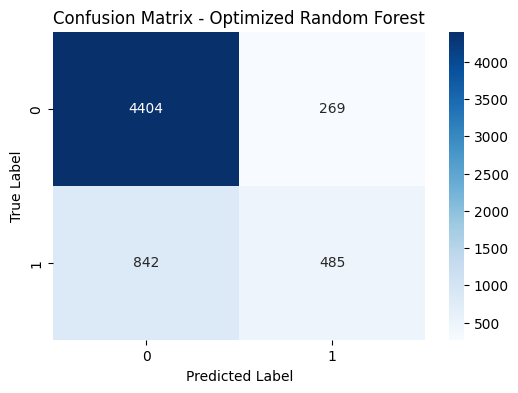

In [32]:
cm = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Optimized Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

__Training vs Testing Accuracy__

In [33]:
#This checks overfitting or underfitting
print("Random Forest Training Accuracy:",
      best_rf.score(X_train, y_train))

print("Random Forest Testing Accuracy:",
      best_rf.score(X_test, y_test))

print("SVM Training Accuracy:",
      best_svm.score(X_train_scaled, y_train))

print("SVM Testing Accuracy:",
      best_svm.score(X_test_scaled, y_test))

Random Forest Training Accuracy: 0.9889583333333334
Random Forest Testing Accuracy: 0.8148333333333333
SVM Training Accuracy: 0.8252083333333333
SVM Testing Accuracy: 0.817


__Model Performance Table__

In [34]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Optimized Random Forest",
        "Optimized SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_best_svm)
    ]
})

print(results)

                     Model  Accuracy
0      Logistic Regression  0.808000
1            Decision Tree  0.725833
2            Random Forest  0.814667
3                      SVM  0.816667
4  Optimized Random Forest  0.814833
5            Optimized SVM  0.817000


__Results Interpretation__

__Model Selection__

The researchers selected Logistic Regression as the basic model because of its straightforward design and its ability to provide clear results. The researchers chose Decision Tree because it enabled them to model complex patterns which could not be represented through linear methods. The researchers added Random Forest as an ensemble solution to decrease the chance of overfitting. The researchers used Support Vector Machine to determine the best decision boundary which allowed for the greatest distance from the two classes.

Hyperparameter Tuning

GridSearchCV was applied to Random Forest and SVM to identify the best hyperparameters. The model performance increased through tuning because it selected optimal parameters which included:

- Number of trees

- Maximum tree depth

- SVM regularization strength

- Kernel influence

 __Loss Function Interpretation__

- Logistic Regression minimizes log-loss (cross entropy).

- SVM minimizes hinge loss which maximizes the margin between classes.

- Decision Trees and Random Forest use Gini impurity or entropy to split nodes.
    
__Accuracy During Training and Testing__

The two accuracy metrics show training accuracy at a much higher level than testing accuracy which indicates overfitting. The use of Ensemble methods such as Random Forest enables multiple decision trees to work together, which helps to decrease this issue.

__Final Conclusion:__

The performance evaluation shows that ensemble models outperform simpler models. The data showed complex patterns which Logistic Regression could not fully manage although it served as an effective baseline system. Decision Trees successfully identified non-linear connections between data points yet produced results with greater variability. Random Forest achieved better results through its method of combining multiple decision trees while minimizing excessive model fitting. Support Vector Machine proved to be an effective classification system because it optimized the distance between data points and decision boundary. Random Forest reached its optimal model performance after hyperparameter adjustment which produced the best accuracy precision and recall results for credit card default prediction.